In [1]:
# 코퍼스 및 기본 토큰화
# %conda install -y nltk
import nltk
from nltk.tokenize import word_tokenize
import numpy as np

In [2]:
# 코퍼스 정의
corpus = {
    '나는 자연어 처리를 공부한다',
    '자연어 처리는 재미있다',
    '나는 데이터 분석과 자연어 처리를 함께 공부한다'
}
# 공백을 기준으로 토큰화
tokenized_corpus = [sentence.split() for sentence in corpus]
tokenized_corpus

[['자연어', '처리는', '재미있다'],
 ['나는', '데이터', '분석과', '자연어', '처리를', '함께', '공부한다'],
 ['나는', '자연어', '처리를', '공부한다']]

In [3]:
# 각 문서의 길이 계산
doc_lengths = [len(tokens) for tokens in tokenized_corpus]

N = len(corpus)  # 문서의 총 수
T = sum(doc_lengths)  # 전체 토큰의 수

# 평균 문서의 수 계산
mean_length = T / N
print(mean_length)

4.666666666666667


In [ ]:
# 어휘 수와 타입 / 토큰 비율 (TTR)

# 어휘 집합
vacabulary = set()
for tokens in tokenized_corpus:
    vacabulary.update(tokens)
print(f'어휘 집합: {vacabulary}')
V_size = len(vacabulary)
print(f'어휘 수: {V_size}')
# TTR 계산
TTR = V_size / T
print(f'타입 / 토큰비율: {TTR:.4f}')

어휘 집합: {'처리를', '데이터', '자연어', '나는', '처리는', '재미있다', '공부한다', '함께', '분석과'}
어휘 수: 9
타입 / 토큰비율: 0.6429


In [12]:
# 토큰 빈도 / 단어 빈도 분포, 희소성
from collections import Counter

# 전체 토큰을 하나의 리스트로 합치기
all_tokens = [token for tokens in tokenized_corpus for token in tokens]
# 토큰 빈도 계산
token_freq = Counter(all_tokens)
print(f'토큰 빈도: {token_freq}')

# 문서, 단어 행렬에서 관측값 계산 - 각 문서 내의 고유단어 등장 수 합계
non_zero_tokens = sum(len(set(tokens)) for tokens in tokenized_corpus)
total_tokens = N * V_size # 전체 관측값 (문서 수 * 어휘 수)
density = non_zero_tokens / total_tokens
sparsity = 1 - density
print(f'값이 있는 칸 수: {non_zero_tokens}')
print(f'문서, 단어 전체 칸 수: {total_tokens}')
print(f'밀도: {density:.4f}')
print(f'희소성: {sparsity:.4f}')

토큰 빈도: Counter({'자연어': 3, '나는': 2, '처리를': 2, '공부한다': 2, '처리는': 1, '재미있다': 1, '데이터': 1, '분석과': 1, '함께': 1})
값이 있는 칸 수: 14
문서, 단어 전체 칸 수: 27
밀도: 0.5185
희소성: 0.4815


In [13]:
# 이상한 나라의 앨리스
import matplotlib.pyplot as plt
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import RegexpTokenizer

# 데이터 다운로드
nltk.download('gutenberg')
nltk.download('stopwords')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\gutenberg.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [19]:
# 이상한 나라의 앨리스 코퍼스 로드
doc_alice = gutenberg.raw('carroll-alice.txt')
# 정규식 이용해 3글자 이상 단어 추출 및 토큰화
tokenizer = RegexpTokenizer(r'\w{3,}')
reg_tokens_alice = tokenizer.tokenize(doc_alice.lower())
# 불용어 제거
english_stopwords = stopwords.words('english')
result_alice = [word for word in reg_tokens_alice if word not in english_stopwords]

# 토큰 빈도 집계
alice_word_count = Counter(result_alice)
print(f'사용한 고유 단어 수: {len(alice_word_count)}')

사용한 고유 단어 수: 2405


In [21]:
# 상위 20개 단어 추출
top_20_words = alice_word_count.most_common(20)
print(f'상위 20개 단어: {top_20_words}')

상위 20개 단어: [('said', 462), ('alice', 398), ('little', 128), ('one', 104), ('know', 88), ('like', 85), ('would', 83), ('went', 83), ('could', 77), ('queen', 75), ('thought', 74), ('time', 71), ('see', 67), ('well', 63), ('king', 63), ('turtle', 59), ('began', 58), ('way', 56), ('hatter', 56), ('mock', 56)]


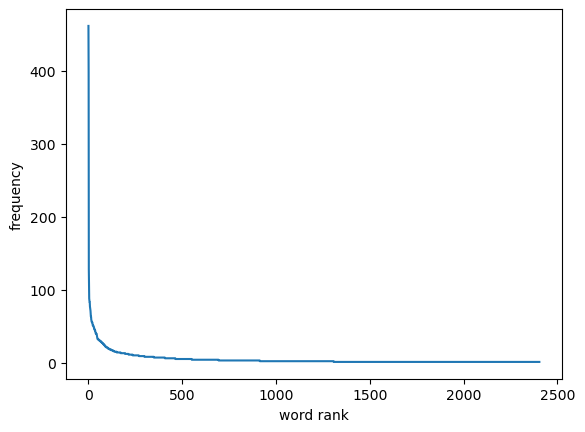

In [ ]:
all_requested = sorted(list(alice_word_count.values()), reverse=True)
plt.plot(all_requested)
plt.xlabel('word rank')
plt.ylabel('frequency')
plt.show()